## Retinal vessel segmentation Using Baseline U-Net and Attention U-Net

In [1]:
import os

file_path = r"C:\Users\HP PC\Downloads\DRIVE"

print(os.listdir(file_path))

['test', 'training']


### Inspect the contents of:

* training
* test

In [2]:
training_path = os.path.join(file_path, "training")

print(os.listdir(training_path))

['1st_manual', 'images', 'mask']


### 1. images

These are:

retinal fundus photographs.

They contain:

* optic disc
* arteries
* veins
* retinal background


2. 1st_manual

These are:

ground truth vessel masks.

Usually:

* white pixels = blood vessels
* black pixels = background

This is what your model will learn to predict.

So:

* this is semantic segmentation.




3. mask

This is VERY important.

These masks define:

* valid retinal region (Field of View).

* Because retinal images are circular.

Outside the circular retina:

* black regions exist
* irrelevant pixels exist


Why FOV Mask Matters

Without masking:
the model may learn:

* black borders
* artificial edges
* background artifacts

instead of vessels.

### visualize all three together.

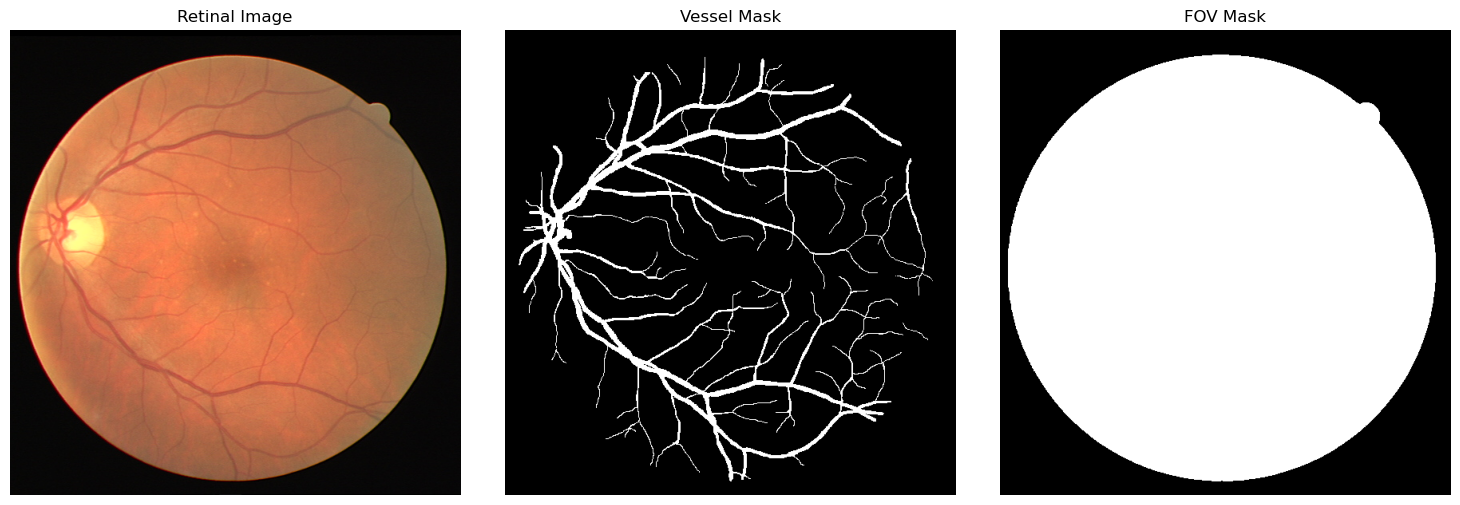

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Paths
training_path = r"C:\Users\HP PC\Downloads\DRIVE\training"

image_folder = os.path.join(training_path, "images")
manual_folder = os.path.join(training_path, "1st_manual")
mask_folder = os.path.join(training_path, "mask")

# Get first files
image_name = os.listdir(image_folder)[0]
manual_name = os.listdir(manual_folder)[0]
mask_name = os.listdir(mask_folder)[0]

# Full paths
image_path = os.path.join(image_folder, image_name)
manual_path = os.path.join(manual_folder, manual_name)
mask_path = os.path.join(mask_folder, mask_name)

# Load images
image = Image.open(image_path)
manual = Image.open(manual_path)
mask = Image.open(mask_path)

# Plot
plt.figure(figsize=(15,5))

# Original retinal image
plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Retinal Image")
plt.axis("off")

# Vessel segmentation mask
plt.subplot(1,3,2)
plt.imshow(manual, cmap="gray")
plt.title("Vessel Mask")
plt.axis("off")

# Field of View mask
plt.subplot(1,3,3)
plt.imshow(mask, cmap="gray")
plt.title("FOV Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

### Why Fundus Imaging Is Important

Doctors analyze fundus images for:

* diabetic retinopathy
* glaucoma
* hypertension
* vessel abnormalities
* retinal diseases



Why Vessel Segmentation Matters

Blood vessels reveal:

* blood circulation health
* retinal disease progression
* systemic diseases

So retinal vessel segmentation has:

huge clinical importance.

### Understand Image Sizes

In [4]:
print(image.size)
print(manual.size)
print(mask.size)

(565, 584)
(565, 584)
(565, 584)


### Convert Images To Arrays

You need numerical tensors eventually.

In [5]:
import numpy as np

image_array = np.array(image)
manual_array = np.array(manual)
mask_array = np.array(mask)

print(image_array.shape)
print(manual_array.shape)
print(mask_array.shape)

(584, 565, 3)
(584, 565)
(584, 565)


### Now inspect:

pixel values.

In [6]:
print(np.unique(manual_array))
print(np.unique(mask_array))

[  0 255]
[  0 255]


### Your Next Pipeline
* 1. Load Images
      ↓
* 2. Green Channel Extraction
      ↓
* 3. Normalize Images
      ↓
* 4. Normalize Masks
      ↓
* 5. Apply FOV Mask
      ↓
* 6. Prepare Image-Mask Pairs
      ↓
* 7. Train/Validation Pipeline

### Extract Green Channel

This is a classic retinal preprocessing step.

In [7]:
green_channel = image_array[:, :, 1]

print(green_channel.shape)

(584, 565)


### WHY GREEN CHANNEL?

Retinal vessels appear:

clearest in the green channel.

This improves:

* vessel contrast
* edge visibility
* segmentation learning

### Visualize Green Channel

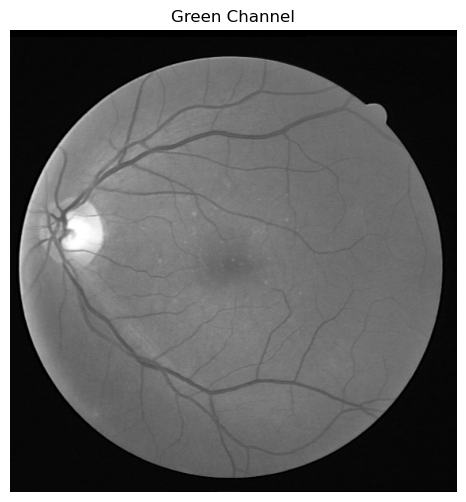

In [8]:
plt.figure(figsize=(6,6))
plt.imshow(green_channel, cmap="gray")
plt.title("Green Channel")
plt.axis("off")
plt.show()

### Normalize Image Intensities

Very important for deep learning.

In [9]:
green_channel = green_channel / 255.0

print(green_channel.min(), green_channel.max())

0.0 1.0


### Normalize Vessel Mask

In [10]:
manual_array = manual_array / 255.0

print(np.unique(manual_array))

[0. 1.]


### Normalize FOV Mask

In [11]:
mask_array = mask_array / 255.0

print(np.unique(mask_array))

[0. 1.]


### Apply FOV Mask

This is VERY important.

In [12]:
preprocessed_image = green_channel * mask_array

### Visualize Final Preprocessed Image

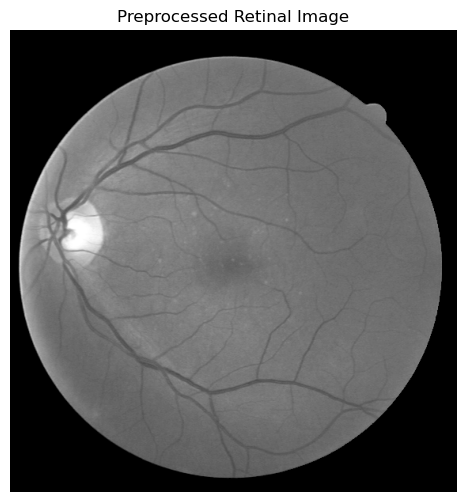

In [13]:
plt.figure(figsize=(6,6))
plt.imshow(preprocessed_image, cmap="gray")
plt.title("Preprocessed Retinal Image")
plt.axis("off")
plt.show()

### Full Pipeline Ahead
* Preprocessing ✅
       ↓
* Dataset Construction
       ↓
* PyTorch Dataset Class
       ↓
* DataLoader
       ↓
* U-Net Baseline

### Import Libraries

In [14]:
import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

### Define Dataset Paths

In [15]:
base_path = r"C:\Users\HP PC\Downloads\DRIVE"

train_path = os.path.join(base_path, "training")

image_dir = os.path.join(train_path, "images")
mask_dir = os.path.join(train_path, "1st_manual")
fov_dir = os.path.join(train_path, "mask")

### Get File Lists

In [16]:
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))
fov_files = sorted(os.listdir(fov_dir))

print(len(image_files))
print(len(mask_files))
print(len(fov_files))

20
20
20


### Create Dataset Class

Now the important part.

In [17]:
class DriveDataset(Dataset):

    def __init__(self, image_dir, mask_dir, fov_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.fov_dir = fov_dir

        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.fov_files = sorted(os.listdir(fov_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        # Image path
        image_path = os.path.join(
            self.image_dir,
            self.image_files[idx]
        )

        # Mask path
        mask_path = os.path.join(
            self.mask_dir,
            self.mask_files[idx]
        )

        # FOV path
        fov_path = os.path.join(
            self.fov_dir,
            self.fov_files[idx]
        )

        # Load image
        image = Image.open(image_path)
        image = np.array(image)

        # Extract green channel
        image = image[:, :, 1]

        # Normalize image
        image = image / 255.0

        # Load vessel mask
        mask = Image.open(mask_path)
        mask = np.array(mask)

        # Normalize vessel mask
        mask = mask / 255.0

        # Load FOV mask
        fov = Image.open(fov_path)
        fov = np.array(fov)

        # Normalize FOV
        fov = fov / 255.0

        # Apply FOV mask
        image = image * fov

        # Convert to tensors
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

### VERY IMPORTANT THINGS HAPPENING HERE

Your dataset class now:

* loads retinal images
* extracts green channel
* normalizes intensities
* applies FOV masking
* loads vessel masks
* converts everything to tensors

This is:

real segmentation preprocessing.

### Create Dataset Object

In [18]:
train_dataset = DriveDataset(
    image_dir,
    mask_dir,
    fov_dir
)

print(len(train_dataset))

20


### Inspect One Sample

In [19]:
image, mask = train_dataset[0]

print(image.shape)
print(mask.shape)

torch.Size([1, 584, 565])
torch.Size([1, 584, 565])


### Visualize Dataset Sample

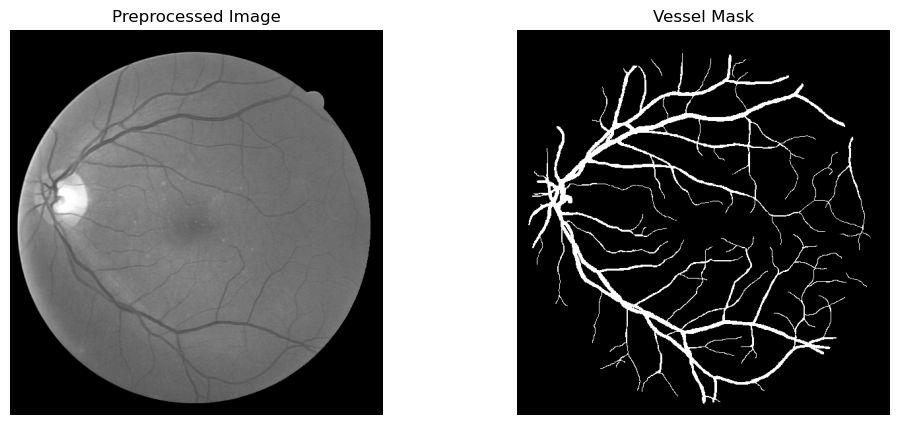

In [20]:
plt.figure(figsize=(12,5))

# Image
plt.subplot(1,2,1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

# Mask
plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Vessel Mask")
plt.axis("off")

plt.show()

### Create DataLoader

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

### the retina contains visible blood vessels.

And those vessels reveal:

* eye health
* vascular health
* neurological health
* systemic disease patterns


Why The Retina Is Special

The retina is one of the few places in the body where doctors can:

directly observe blood vessels noninvasively.

Without surgery.

That makes retinal imaging extremely valuable medically.

* What Doctors Look For

Radiologists, ophthalmologists, and retinal specialists examine:

* Vessel Property	            *Possible Meaning
* vessel narrowing	            *hypertension
* vessel leakage	            *diabetic retinopathy
* abnormal branching	        *vascular disease
* blocked vessels	            *retinal occlusion
* swelling	                    *inflammation
* tiny aneurysms	            *diabetes
* hemorrhages	                *retinal damage

### verify DataLoader output.

In [22]:
for images, masks in train_loader:

    print(images.shape)
    print(masks.shape)

    break

torch.Size([2, 1, 584, 565])
torch.Size([2, 1, 584, 565])


### YOU HAVE NOW COMPLETED
Stage	Status
* Dataset loading	✅
* Visualization	✅
* Preprocessing	✅
* FOV masking	✅
* Dataset class	✅
* DataLoader	✅
* Batch verification	✅

###  Lets start training with U-Net baseline

### Import PyTorch Modules

In [23]:
import torch.nn as nn

### Create Double Convolution Block

This is the core feature extraction unit.

In [24]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

### WHY DOUBLE CONV?

Each block learns:

* vessel edges
* contours
* textures
* spatial patterns

Repeated convolutions improve:

*feature representation.

### Build U-Net Architecture

In [25]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(128, 64)

        # Final output
        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        # Bottleneck
        bn = self.bottleneck(p2)

        # Decoder
        up1 = self.up1(bn)

        # Match shapes
        if up1.shape != d2.shape:
            up1 = nn.functional.interpolate(
                up1,
                size=d2.shape[2:]
            )

        up1 = torch.cat([up1, d2], dim=1)
        up1 = self.conv1(up1)

        up2 = self.up2(up1)

        if up2.shape != d1.shape:
            up2 = nn.functional.interpolate(
                up2,
                size=d1.shape[2:]
            )

        up2 = torch.cat([up2, d1], dim=1)
        up2 = self.conv2(up2)

        return torch.sigmoid(self.final(up2))

### Initialize Model

In [26]:
model = UNet()

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  

### Test Forward Pass

In [27]:
sample_images, sample_masks = next(iter(train_loader))

outputs = model(sample_images)

print(outputs.shape)

torch.Size([2, 1, 584, 565])


### Your Pipeline Is Now Fully Functional

You officially have:

Component	Status
* Dataset loading	✅
* Preprocessing	✅
* FOV masking	✅
* Dataset class	✅
* DataLoader	✅
* U-Net architecture	✅
* Forward propagation	✅

### Define Loss Function

For baseline U-Net:
use:

* Binary Cross Entropy Loss

In [28]:
criterion = nn.BCELoss()

### Define Optimizer

In [29]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### Import Split Utility

In [30]:
from torch.utils.data import random_split

### Split Dataset

In [31]:
train_size = 16
val_size = 4

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

### Create DataLoaders

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

### Dice Score Function

In [33]:
def dice_score(preds, targets, smooth=1e-6):

    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        preds.sum() + targets.sum() + smooth
    )

    return dice.item()

### Define Loss + Optimizer

In [34]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### Training Loop

In [35]:
num_epochs = 20

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, masks)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():

        for val_images, val_masks in val_loader:

            # Forward pass
            val_outputs = model(val_images)

            # Validation loss
            loss = criterion(
                val_outputs,
                val_masks
            )

            val_loss += loss.item()

            # Dice score
            val_dice += dice_score(
                val_outputs,
                val_masks
            )

    avg_val_loss = val_loss / len(val_loader)

    avg_val_dice = val_dice / len(val_loader)

    # =========================
    # PRINT RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice Score: {avg_val_dice:.4f}"
    )

Epoch [1/20] | Train Loss: 0.5955 | Val Loss: 0.4277 | Dice Score: 0.0000
Epoch [2/20] | Train Loss: 0.4047 | Val Loss: 0.2982 | Dice Score: 0.0000
Epoch [3/20] | Train Loss: 0.2995 | Val Loss: 0.2817 | Dice Score: 0.0000
Epoch [4/20] | Train Loss: 0.2722 | Val Loss: 0.2698 | Dice Score: 0.0000
Epoch [5/20] | Train Loss: 0.2646 | Val Loss: 0.2657 | Dice Score: 0.0000
Epoch [6/20] | Train Loss: 0.2621 | Val Loss: 0.2643 | Dice Score: 0.0000
Epoch [7/20] | Train Loss: 0.2616 | Val Loss: 0.2632 | Dice Score: 0.0000
Epoch [8/20] | Train Loss: 0.2594 | Val Loss: 0.2622 | Dice Score: 0.0000
Epoch [9/20] | Train Loss: 0.2582 | Val Loss: 0.2614 | Dice Score: 0.0000
Epoch [10/20] | Train Loss: 0.2576 | Val Loss: 0.2605 | Dice Score: 0.0000
Epoch [11/20] | Train Loss: 0.2569 | Val Loss: 0.2597 | Dice Score: 0.0000
Epoch [12/20] | Train Loss: 0.2566 | Val Loss: 0.2596 | Dice Score: 0.0000
Epoch [13/20] | Train Loss: 0.2565 | Val Loss: 0.2595 | Dice Score: 0.0000
Epoch [14/20] | Train Loss: 0.2568

In [36]:
images, masks = next(iter(train_loader))

print(masks.min())
print(masks.max())
print(torch.unique(masks))

tensor(0.)
tensor(1.)
tensor([0., 1.])


In [37]:
images, masks = next(iter(train_loader))

with torch.no_grad():

    outputs = model(images)

print(outputs.min())
print(outputs.max())
print(outputs.mean())

tensor(6.4187e-05)
tensor(0.1521)
tensor(0.0623)


In [38]:
def dice_score_02(preds, targets, smooth=1e-6):

    preds = (preds > 0.2).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        preds.sum() + targets.sum() + smooth
    )

    return dice.item()

In [39]:
images, masks = next(iter(val_loader))

with torch.no_grad():
    outputs = model(images)

print(dice_score_02(outputs, masks))

1.6265981617191727e-11


### Keep Your Existing U-Net Model

In [40]:
model = UNet()

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  

### Define Dice Loss

Add this in a new cell after the U-Net definition.

In [41]:
import torch.nn as nn

class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

### Define Dice Score Metric

In [42]:
def dice_score(preds, targets, smooth=1e-6):

    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        preds.sum() + targets.sum() + smooth
    )

    return dice.item()

### Define BCE + Dice Loss

In [43]:
bce_loss = nn.BCELoss()

dice_loss = DiceLoss()

### Define Optimizer

In [44]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### Verify Everything Is Ready

In [45]:
print(model)
print(optimizer)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  

### Training Loop (BCE + Dice)

This replaces the old BCE-only training loop.

In [46]:
best_dice = 0

In [47]:
num_epochs = 20

for epoch in range(num_epochs):

    # ==========================
    # TRAINING
    # ==========================
    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        outputs = model(images)

        # BCE Loss
        bce = bce_loss(outputs, masks)

        # Dice Loss
        dice = dice_loss(outputs, masks)

        # Combined Loss
        loss = bce + dice

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():

        for val_images, val_masks in val_loader:

            val_outputs = model(val_images)

            # Validation BCE Loss
            bce = bce_loss(
                val_outputs,
                val_masks
            )

            # Validation Dice Loss
            dice = dice_loss(
                val_outputs,
                val_masks
            )

            # Combined Validation Loss
            loss = bce + dice

            val_loss += loss.item()

            # Dice Metric
            val_dice += dice_score(
                val_outputs,
                val_masks
            )

    avg_val_loss = val_loss / len(val_loader)

    avg_val_dice = val_dice / len(val_loader)

    # ==========================
    # SAVE BEST MODEL
    # ==========================
    if avg_val_dice > best_dice:

        best_dice = avg_val_dice

        torch.save(
            model.state_dict(),
            "best_unet_drive.pth"
        )

        print(
            f"Best model saved! Dice={best_dice:.4f}"
        )

    # ==========================
    # PRINT RESULTS
    # ==========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice Score: {avg_val_dice:.4f}"
    )

Best model saved! Dice=0.0000
Epoch [1/20] | Train Loss: 1.4275 | Val Loss: 1.2983 | Dice Score: 0.0000
Epoch [2/20] | Train Loss: 1.2562 | Val Loss: 1.2039 | Dice Score: 0.0000
Epoch [3/20] | Train Loss: 1.1729 | Val Loss: 1.1506 | Dice Score: 0.0000
Epoch [4/20] | Train Loss: 1.1375 | Val Loss: 1.1311 | Dice Score: 0.0000
Epoch [5/20] | Train Loss: 1.1222 | Val Loss: 1.1199 | Dice Score: 0.0000
Epoch [6/20] | Train Loss: 1.1148 | Val Loss: 1.1107 | Dice Score: 0.0000
Epoch [7/20] | Train Loss: 1.1098 | Val Loss: 1.1044 | Dice Score: 0.0000
Epoch [8/20] | Train Loss: 1.1056 | Val Loss: 1.1066 | Dice Score: 0.0000
Epoch [9/20] | Train Loss: 1.1059 | Val Loss: 1.0971 | Dice Score: 0.0000
Epoch [10/20] | Train Loss: 1.0976 | Val Loss: 1.0982 | Dice Score: 0.0000
Epoch [11/20] | Train Loss: 1.0937 | Val Loss: 1.0909 | Dice Score: 0.0000
Epoch [12/20] | Train Loss: 1.0932 | Val Loss: 1.0823 | Dice Score: 0.0000
Epoch [13/20] | Train Loss: 1.0780 | Val Loss: 1.0970 | Dice Score: 0.0000
Best

In [48]:
images, masks = next(iter(val_loader))

model.eval()

with torch.no_grad():

    outputs = model(images)

print("Min:", outputs.min().item())
print("Max:", outputs.max().item())
print("Mean:", outputs.mean().item())

Min: 1.2019777386740316e-05
Max: 0.49650877714157104
Mean: 0.191165030002594


In [49]:
images, masks = next(iter(val_loader))

model.eval()

with torch.no_grad():
    outputs = model(images)

preds = (outputs > 0.5).float()

print("Ground Truth Vessel Pixels:", masks.sum().item())
print("Predicted Vessel Pixels:", preds.sum().item())

Ground Truth Vessel Pixels: 61478.0
Predicted Vessel Pixels: 0.0


In [50]:
for thresh in [0.1, 0.2, 0.3, 0.4]:

    preds = (outputs > thresh).float()

    intersection = (preds * masks).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        preds.sum() + masks.sum() + 1e-6
    )

    print(
        f"Threshold={thresh}  Dice={dice.item():.4f}"
    )

Threshold=0.1  Dice=0.2467
Threshold=0.2  Dice=0.2507
Threshold=0.3  Dice=0.4058
Threshold=0.4  Dice=0.3412


### Let us visualise predictions

In [51]:
model.load_state_dict(
    torch.load("best_unet_drive.pth")
)

model.eval()

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  

### Get One Validation Sample

In [52]:
images, masks = next(iter(val_loader))

print(images.shape)
print(masks.shape)

torch.Size([2, 1, 584, 565])
torch.Size([2, 1, 584, 565])


### Generate Predictions

In [53]:
with torch.no_grad():

    outputs = model(images)

### Create Binary Vessel Mask

Since we discovered 0.5 is too strict, use:

In [54]:
pred_masks = (outputs > 0.2).float()

### Visualize First Sample

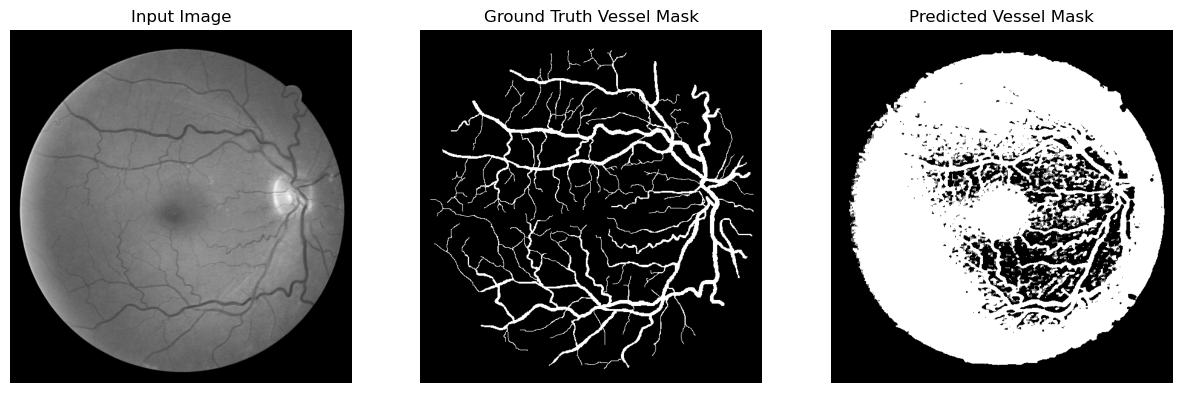

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Original retinal image
plt.subplot(1,3,1)
plt.imshow(images[0][0], cmap="gray")
plt.title("Input Image")
plt.axis("off")

# Ground truth
plt.subplot(1,3,2)
plt.imshow(masks[0][0], cmap="gray")
plt.title("Ground Truth Vessel Mask")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.imshow(pred_masks[0][0], cmap="gray")
plt.title("Predicted Vessel Mask")
plt.axis("off")

plt.show()

### View Multiple Samples

After viewing one image, run:

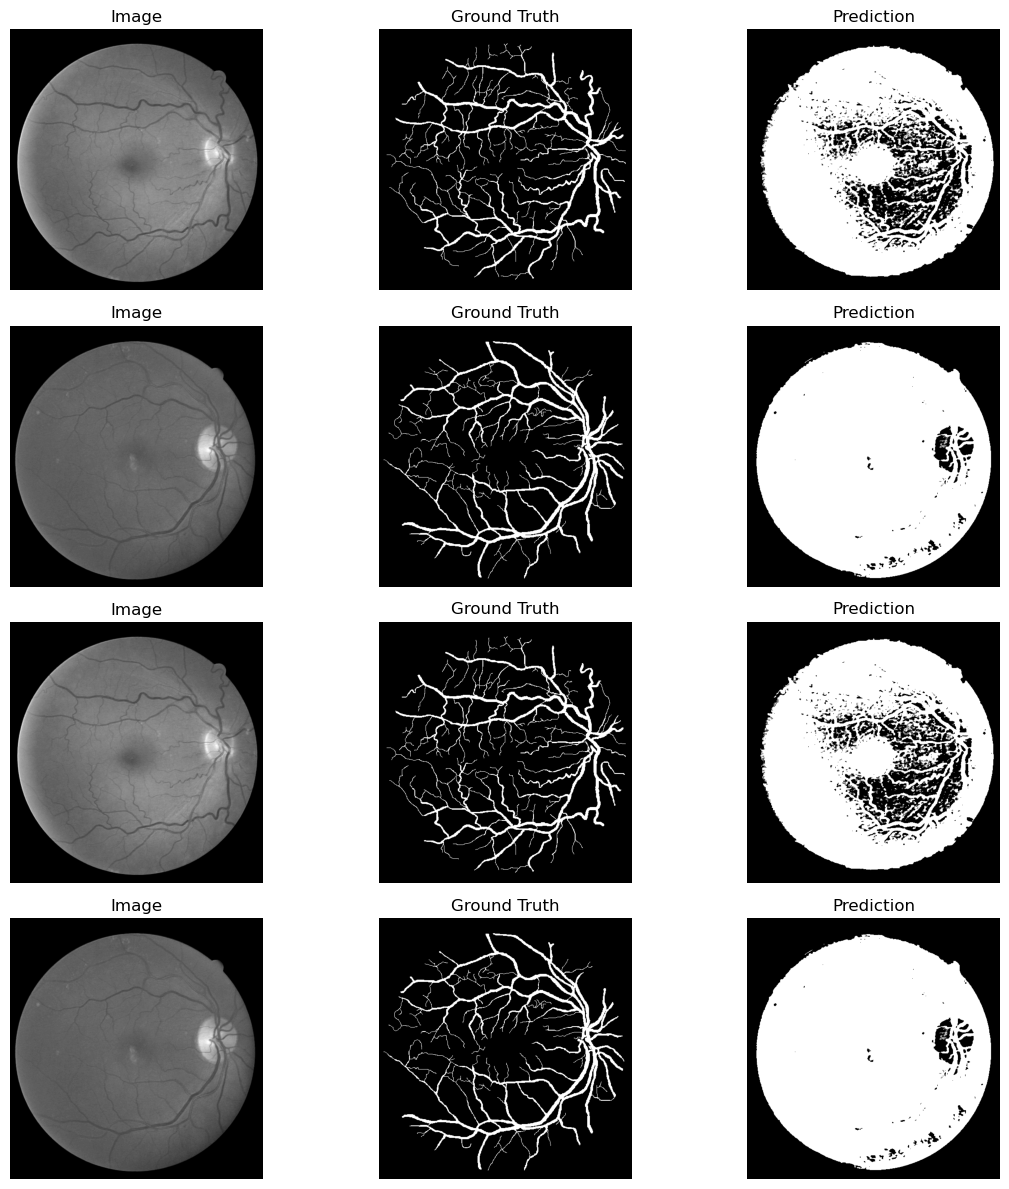

In [56]:
plt.figure(figsize=(12,12))

for i in range(4):

    plt.subplot(4,3,3*i+1)
    plt.imshow(images[i%2][0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(4,3,3*i+2)
    plt.imshow(masks[i%2][0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4,3,3*i+3)
    plt.imshow(pred_masks[i%2][0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

###  Observing the validation prediction showed that the model has not learned much. Let us push the U-Net baseline training to 50 epochs

### Imports

In [57]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image

### Verify Dataset Paths

In [58]:
import os

file_path = r"C:\Users\HP PC\Downloads\DRIVE"

training_path = os.path.join(
    file_path,
    "training"
)

image_dir = os.path.join(
    training_path,
    "images"
)

mask_dir = os.path.join(
    training_path,
    "1st_manual"
)

fov_dir = os.path.join(
    training_path,
    "mask"
)

print(len(os.listdir(image_dir)))
print(len(os.listdir(mask_dir)))
print(len(os.listdir(fov_dir)))

20
20
20


### Create Dataset

In [59]:
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset


class DriveDataset(Dataset):

    def __init__(self, image_dir, mask_dir, fov_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.fov_dir = fov_dir

        self.image_files = sorted(
            os.listdir(image_dir)
        )

        self.mask_files = sorted(
            os.listdir(mask_dir)
        )

        self.fov_files = sorted(
            os.listdir(fov_dir)
        )

    def __len__(self):

        return len(self.image_files)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.image_files[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.mask_files[idx]
        )

        image = Image.open(
            image_path
        ).convert("L")

        mask = Image.open(
            mask_path
        ).convert("L")

        image = np.array(image) / 255.0

        mask = np.array(mask) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

### Create Dataset

In [60]:
dataset = DriveDataset(
    image_dir,
    mask_dir,
    fov_dir
)

print(len(dataset))

20


### Create Train / Validation Split

In [61]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(
    dataset,
    [16, 4]
)

print(len(train_dataset))
print(len(val_dataset))

16
4


### Create DataLoaders

In [62]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

### Verify Shapes

In [63]:
images, masks = next(
    iter(train_loader)
)

print(images.shape)
print(masks.shape)

torch.Size([2, 1, 584, 565])
torch.Size([2, 1, 584, 565])


### U-Net Architecture

Use this U-Net exactly.

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.down1 = DoubleConv(1, 64)

        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)

        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # Decoder

        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.conv1 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder

        c1 = self.down1(x)

        p1 = self.pool1(c1)

        c2 = self.down2(p1)

        p2 = self.pool2(c2)

        # Bottleneck

        bottleneck = self.bottleneck(p2)

        # Decoder 1

        u1 = self.up1(bottleneck)

        u1 = F.interpolate(
            u1,
            size=c2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        u1 = torch.cat(
            [u1, c2],
            dim=1
        )

        u1 = self.conv1(u1)

        # Decoder 2

        u2 = self.up2(u1)

        u2 = F.interpolate(
            u2,
            size=c1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        u2 = torch.cat(
            [u2, c1],
            dim=1
        )

        u2 = self.conv2(u2)

        output = self.final(u2)

        return torch.sigmoid(output)

### Create Model

In [68]:
model = UNet()

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  

### Verify Output Shape

Before training:

In [69]:
images, masks = next(iter(train_loader))

outputs = model(images)

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Outputs:", outputs.shape)

Images: torch.Size([2, 1, 584, 565])
Masks: torch.Size([2, 1, 584, 565])
Outputs: torch.Size([2, 1, 584, 565])


### Dice Loss

In [70]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):

        super().__init__()

        self.smooth = smooth

    def forward(self, preds, targets):

        preds = preds.view(-1)

        targets = targets.view(-1)

        intersection = (
            preds * targets
        ).sum()

        dice = (
            2 * intersection + self.smooth
        ) / (
            preds.sum()
            + targets.sum()
            + self.smooth
        )

        return 1 - dice

### Dice Metric

In [71]:
def dice_score(
    preds,
    targets,
    smooth=1e-6
):

    preds = (
        preds > 0.2
    ).float()

    preds = preds.view(-1)

    targets = targets.view(-1)

    intersection = (
        preds * targets
    ).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        preds.sum()
        + targets.sum()
        + smooth
    )

    return dice.item()

### Loss Functions + Optimizer

In [72]:
import torch.optim as optim

bce_loss = nn.BCELoss()

dice_loss = DiceLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

best_dice = 0

In [73]:
test_output = model(images)

print(
    "Prediction range:",
    test_output.min().item(),
    test_output.max().item()
)

Prediction range: 0.46834197640419006 0.4696575403213501


### Training Loop

In [74]:
best_dice = 0

num_epochs = 50

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================

    model.train()

    train_loss = 0

    for images, masks in train_loader:

        outputs = model(images)

        bce = bce_loss(
            outputs,
            masks
        )

        dice = dice_loss(
            outputs,
            masks
        )

        loss = bce + dice

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = (
        train_loss / len(train_loader)
    )

    # =========================
    # Validation
    # =========================

    model.eval()

    val_loss = 0

    val_dice = 0

    with torch.no_grad():

        for val_images, val_masks in val_loader:

            val_outputs = model(
                val_images
            )

            bce = bce_loss(
                val_outputs,
                val_masks
            )

            dice = dice_loss(
                val_outputs,
                val_masks
            )

            loss = bce + dice

            val_loss += loss.item()

            val_dice += dice_score(
                val_outputs,
                val_masks
            )

    avg_val_loss = (
        val_loss / len(val_loader)
    )

    avg_val_dice = (
        val_dice / len(val_loader)
    )

    # =========================
    # Save Best Model
    # =========================

    if avg_val_dice > best_dice:

        best_dice = avg_val_dice

        torch.save(
            model.state_dict(),
            "best_unet_drive.pth"
        )

        print(
            f"\nBest model saved! Dice={best_dice:.4f}"
        )

    # =========================
    # Epoch Results
    # =========================

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice Score: {avg_val_dice:.4f} | "
        f"Best Dice: {best_dice:.4f}"
    )


Best model saved! Dice=0.1486
Epoch [1/50] | Train Loss: 1.4070 | Val Loss: 1.2845 | Dice Score: 0.1486 | Best Dice: 0.1486
Epoch [2/50] | Train Loss: 1.2384 | Val Loss: 1.1509 | Dice Score: 0.0000 | Best Dice: 0.1486

Best model saved! Dice=0.2121
Epoch [3/50] | Train Loss: 1.1500 | Val Loss: 1.1289 | Dice Score: 0.2121 | Best Dice: 0.2121

Best model saved! Dice=0.2136
Epoch [4/50] | Train Loss: 1.1285 | Val Loss: 1.1153 | Dice Score: 0.2136 | Best Dice: 0.2136

Best model saved! Dice=0.2636
Epoch [5/50] | Train Loss: 1.1219 | Val Loss: 1.1142 | Dice Score: 0.2636 | Best Dice: 0.2636
Epoch [6/50] | Train Loss: 1.1171 | Val Loss: 1.1109 | Dice Score: 0.2469 | Best Dice: 0.2636
Epoch [7/50] | Train Loss: 1.1154 | Val Loss: 1.1121 | Dice Score: 0.2160 | Best Dice: 0.2636
Epoch [8/50] | Train Loss: 1.1132 | Val Loss: 1.1068 | Dice Score: 0.0033 | Best Dice: 0.2636
Epoch [9/50] | Train Loss: 1.1119 | Val Loss: 1.1081 | Dice Score: 0.2180 | Best Dice: 0.2636
Epoch [10/50] | Train Loss: 1.

### Let us inspect the predicted the validation samples

In [75]:
model.load_state_dict(
    torch.load("best_unet_drive.pth")
)

model.eval()

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  

In [76]:
model = UNet()

model.load_state_dict(
    torch.load("best_unet_drive.pth")
)

model.eval()

print("Best model loaded successfully")

Best model loaded successfully


### Get One Validation Sample

In [77]:
image, mask = val_dataset[0]

print(image.shape)
print(mask.shape)

torch.Size([1, 584, 565])
torch.Size([1, 584, 565])


### Generate Prediction

In [78]:
with torch.no_grad():

    prediction = model(
        image.unsqueeze(0)
    )

prediction = prediction.squeeze().numpy()

print(
    prediction.min(),
    prediction.max()
)

3.677804e-09 0.99983263


### Convert Prediction to Binary Vessel Mask

Use the same threshold that worked during training:

In [79]:
binary_prediction = (
    prediction > 0.2
).astype("float32")

### Visualize

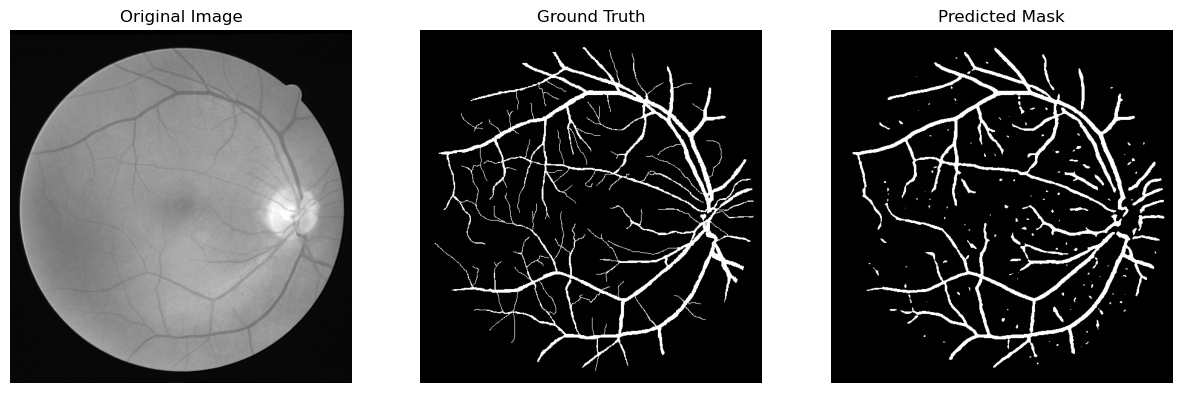

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Original image
plt.subplot(1,3,1)
plt.imshow(
    image.squeeze(),
    cmap="gray"
)
plt.title("Original Image")
plt.axis("off")

# Ground truth
plt.subplot(1,3,2)
plt.imshow(
    mask.squeeze(),
    cmap="gray"
)
plt.title("Ground Truth")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.imshow(
    binary_prediction,
    cmap="gray"
)
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

### Let us view two more validation samples (Sample 2)

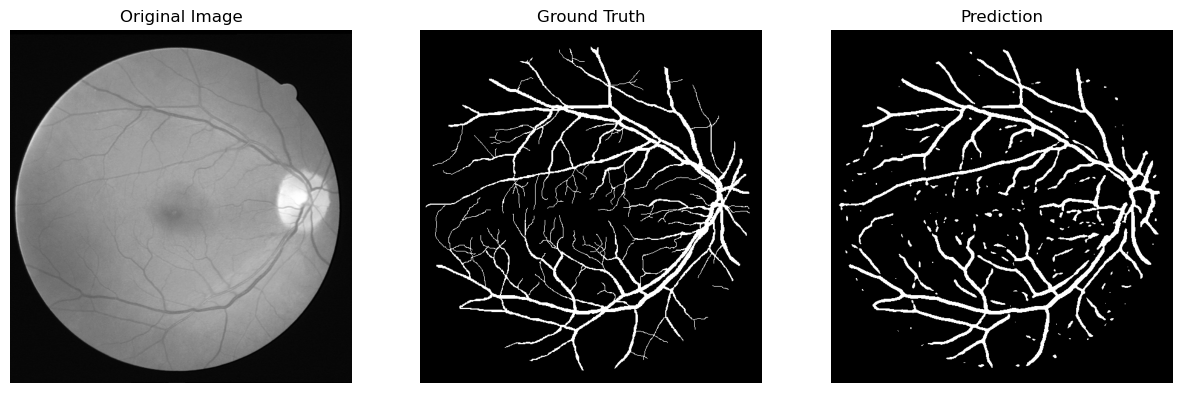

In [81]:
image, mask = val_dataset[1]

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0)
    )

prediction = prediction.squeeze().numpy()

binary_prediction = (
    prediction > 0.2
).astype("float32")

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(
    image.squeeze(),
    cmap="gray"
)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    mask.squeeze(),
    cmap="gray"
)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(
    binary_prediction,
    cmap="gray"
)
plt.title("Prediction")
plt.axis("off")

plt.show()

### Sample 3

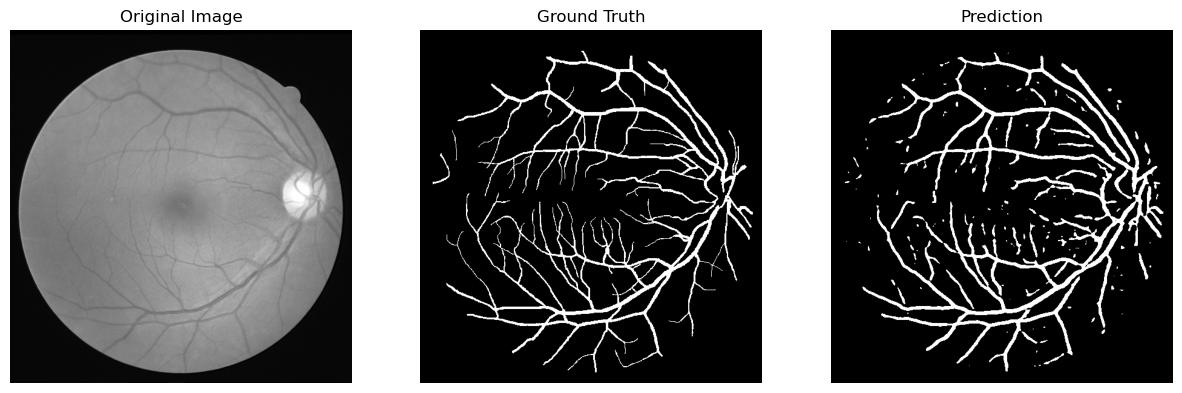

In [82]:
image, mask = val_dataset[2]

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0)
    )

prediction = prediction.squeeze().numpy()

binary_prediction = (
    prediction > 0.2
).astype("float32")

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(
    image.squeeze(),
    cmap="gray"
)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    mask.squeeze(),
    cmap="gray"
)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(
    binary_prediction,
    cmap="gray"
)
plt.title("Prediction")
plt.axis("off")

plt.show()

### Generate Predictions for 3 Samples

In [83]:
samples = []

for idx in range(3):

    image, mask = val_dataset[idx]

    with torch.no_grad():

        prediction = model(
            image.unsqueeze(0)
        )

    prediction = prediction.squeeze().numpy()

    binary_prediction = (
        prediction > 0.2
    ).astype("float32")

    samples.append(
        (
            image.squeeze().numpy(),
            mask.squeeze().numpy(),
            binary_prediction
        )
    )

### : Create Comparison Figure

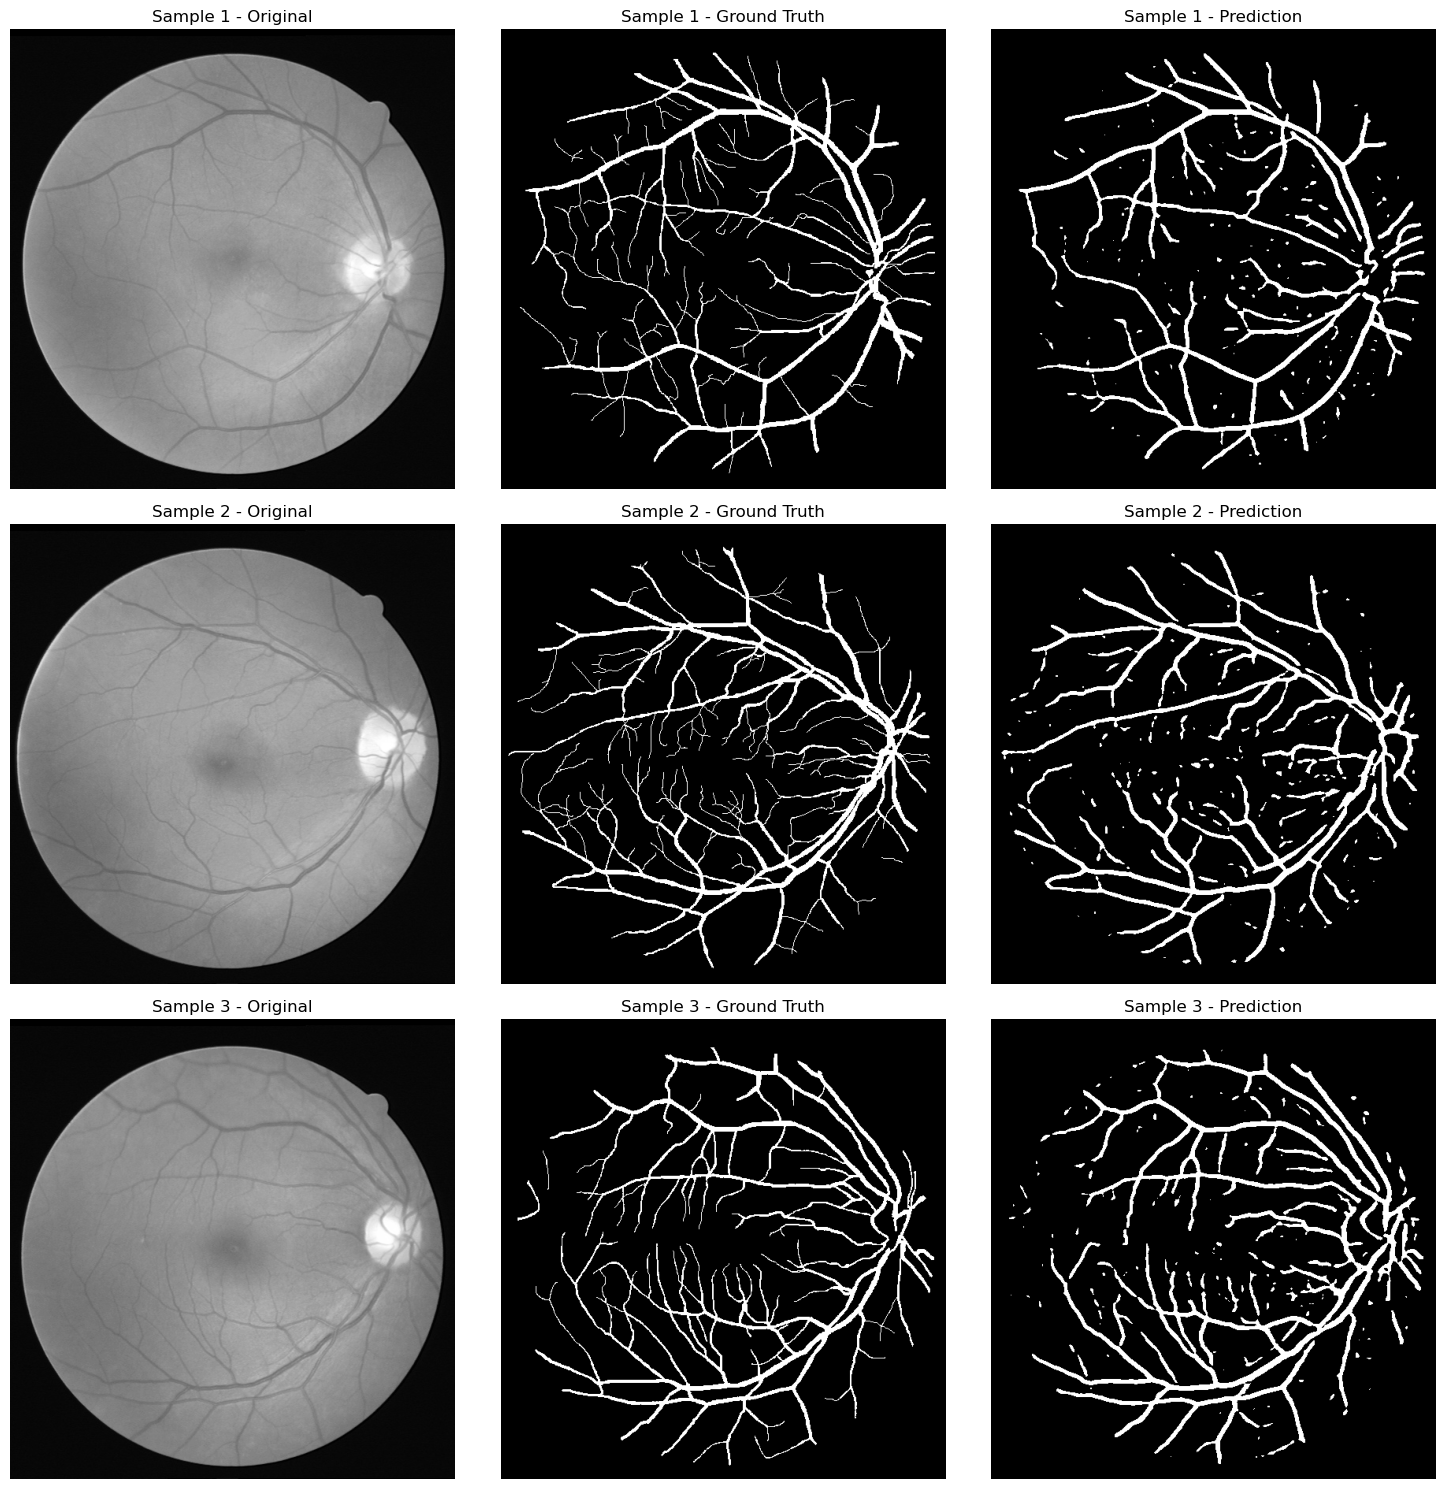

In [84]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15,15)
)

for i in range(3):

    image, mask, pred = samples[i]

    # Original
    axes[i,0].imshow(
        image,
        cmap="gray"
    )

    axes[i,0].set_title(
        f"Sample {i+1} - Original"
    )

    axes[i,0].axis("off")

    # Ground Truth
    axes[i,1].imshow(
        mask,
        cmap="gray"
    )

    axes[i,1].set_title(
        f"Sample {i+1} - Ground Truth"
    )

    axes[i,1].axis("off")

    # Prediction
    axes[i,2].imshow(
        pred,
        cmap="gray"
    )

    axes[i,2].set_title(
        f"Sample {i+1} - Prediction"
    )

    axes[i,2].axis("off")

plt.tight_layout()

plt.show()

### Current Status

We have successfully completed:

* Dataset Preparation ✓
* PyTorch Dataset ✓
* DataLoader ✓
* Baseline U-Net ✓
* BCE + Dice Loss ✓
* 50 Epoch Training ✓
* Best Model Saving ✓
* Validation Metrics ✓
* Visual Inspection ✓

This is a complete baseline retinal vessel segmentation pipeline.

### We should Now move to Attention U-Net

### New Workflow
* Baseline U-Net ✓
      ↓
* Attention U-Net
      ↓
* 50 Epoch Training
      ↓
* Best Model Saving
      ↓
* Visual Comparison
      ↓
* Dice Comparison
      ↓
* Research Conclusion

### Attention Gate

The attention gate learns:

* Decoder Feature
        +
* Encoder Feature
        ↓
* Attention Map
        ↓
* Important Vessel Features

This helps retain weak vessel signals that ordinary skip connections sometimes pass through poorly.

In [85]:
import torch
import torch.nn as nn


class AttentionGate(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

### Test the Gate

In [86]:
gate = AttentionGate(
    F_g=128,
    F_l=128,
    F_int=64
)

print(gate)

AttentionGate(
  (W_g): Sequential(
    (0): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (W_x): Sequential(
    (0): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (psi): Sequential(
    (0): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Sigmoid()
  )
  (relu): ReLU(inplace=True)
)


### Reason for Attension U-Net

### In the baseline U-Net we had:

* Encoder Feature
      ↓
* Direct Skip Connection
      ↓
* Decoder

In Attention U-Net we now have:

* Encoder Feature
      ↓
* Attention Gate
      ↓
* Filtered Skip Connection
      ↓
* Decoder

The gate suppresses irrelevant background information and highlights vessel features.

For retinal vessel segmentation this is useful because:

* Large vessels → already easy

* Tiny vessels → difficult

* Capillaries → difficult

* Terminal branches → difficult

Attention tries to preserve these weak structures.

### Build Attention U-Net

We will reuse your existing:

In [87]:
DoubleConv


__main__.DoubleConv

In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.down1 = DoubleConv(1, 64)

        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)

        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # Attention Gates

        self.att1 = AttentionGate(
            F_g=128,
            F_l=128,
            F_int=64
        )

        self.att2 = AttentionGate(
            F_g=64,
            F_l=64,
            F_int=32
        )

        # Decoder

        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.conv1 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder

        c1 = self.down1(x)

        p1 = self.pool1(c1)

        c2 = self.down2(p1)

        p2 = self.pool2(c2)

        # Bottleneck

        bottleneck = self.bottleneck(p2)

        # Decoder 1

        u1 = self.up1(bottleneck)

        u1 = F.interpolate(
            u1,
            size=c2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        c2_att = self.att1(
            u1,
            c2
        )

        u1 = torch.cat(
            [u1, c2_att],
            dim=1
        )

        u1 = self.conv1(u1)

        # Decoder 2

        u2 = self.up2(u1)

        u2 = F.interpolate(
            u2,
            size=c1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        c1_att = self.att2(
            u2,
            c1
        )

        u2 = torch.cat(
            [u2, c1_att],
            dim=1
        )

        u2 = self.conv2(u2)

        output = self.final(u2)

        return torch.sigmoid(output)

### Define Attention U-Net

In [89]:
attention_model = AttentionUNet()

print(attention_model)

AttentionUNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)

### Then verify shapes:

In [90]:
images, masks = next(iter(train_loader))

outputs = attention_model(images)

print(images.shape)
print(outputs.shape)

torch.Size([2, 1, 584, 565])
torch.Size([2, 1, 584, 565])


### Create Attention Model

In [91]:
attention_model = AttentionUNet()

### Optimizer

In [92]:
import torch.optim as optim

attention_optimizer = optim.Adam(
    attention_model.parameters(),
    lr=0.001
)

### Best Dice Tracker

In [93]:
best_attention_dice = 0

### Attention U-Net Training Loop

In [94]:
best_attention_dice = 0

num_epochs = 50

for epoch in range(num_epochs):

    # ==================================
    # TRAINING
    # ==================================

    attention_model.train()

    train_loss = 0

    for images, masks in train_loader:

        outputs = attention_model(images)

        bce = bce_loss(
            outputs,
            masks
        )

        dice = dice_loss(
            outputs,
            masks
        )

        loss = bce + dice

        attention_optimizer.zero_grad()

        loss.backward()

        attention_optimizer.step()

        train_loss += loss.item()

    avg_train_loss = (
        train_loss / len(train_loader)
    )

    # ==================================
    # VALIDATION
    # ==================================

    attention_model.eval()

    val_loss = 0

    val_dice = 0

    with torch.no_grad():

        for val_images, val_masks in val_loader:

            val_outputs = attention_model(
                val_images
            )

            bce = bce_loss(
                val_outputs,
                val_masks
            )

            dice = dice_loss(
                val_outputs,
                val_masks
            )

            loss = bce + dice

            val_loss += loss.item()

            val_dice += dice_score(
                val_outputs,
                val_masks
            )

    avg_val_loss = (
        val_loss / len(val_loader)
    )

    avg_val_dice = (
        val_dice / len(val_loader)
    )

    # ==================================
    # SAVE BEST MODEL
    # ==================================

    if avg_val_dice > best_attention_dice:

        best_attention_dice = avg_val_dice

        torch.save(
            attention_model.state_dict(),
            "best_attention_unet_drive.pth"
        )

        print(
            f"\nBest Attention U-Net Saved! "
            f"Dice={best_attention_dice:.4f}"
        )

    # ==================================
    # DISPLAY RESULTS
    # ==================================

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice Score: {avg_val_dice:.4f} | "
        f"Best Dice: {best_attention_dice:.4f}"
    )


Best Attention U-Net Saved! Dice=0.0282
Epoch [1/50] | Train Loss: 1.4118 | Val Loss: 1.2515 | Dice Score: 0.0282 | Best Dice: 0.0282
Epoch [2/50] | Train Loss: 1.1809 | Val Loss: 1.1911 | Dice Score: 0.0000 | Best Dice: 0.0282
Epoch [3/50] | Train Loss: 1.1361 | Val Loss: 1.1625 | Dice Score: 0.0000 | Best Dice: 0.0282
Epoch [4/50] | Train Loss: 1.1167 | Val Loss: 1.1464 | Dice Score: 0.0000 | Best Dice: 0.0282
Epoch [5/50] | Train Loss: 1.0974 | Val Loss: 1.1223 | Dice Score: 0.0000 | Best Dice: 0.0282
Epoch [6/50] | Train Loss: 1.0641 | Val Loss: 1.2202 | Dice Score: 0.0000 | Best Dice: 0.0282

Best Attention U-Net Saved! Dice=0.2108
Epoch [7/50] | Train Loss: 1.0229 | Val Loss: 1.1847 | Dice Score: 0.2108 | Best Dice: 0.2108
Epoch [8/50] | Train Loss: 0.8817 | Val Loss: 1.5787 | Dice Score: 0.0000 | Best Dice: 0.2108
Epoch [9/50] | Train Loss: 0.9299 | Val Loss: 2.3132 | Dice Score: 0.0000 | Best Dice: 0.2108

Best Attention U-Net Saved! Dice=0.2422
Epoch [10/50] | Train Loss: 0.7

### Create Fresh Attention U-Net

In [95]:
attention_model = AttentionUNet()

### Load Best Checkpoint

In [96]:
attention_model.load_state_dict(
    torch.load("best_attention_unet_drive.pth")
)

attention_model.eval()

print("Best Attention U-Net loaded successfully")

Best Attention U-Net loaded successfully


### Create Side-by-Side Comparison

This will show:

* Original
* Ground Truth
* Attention U-Net Prediction

for 3 validation samples.

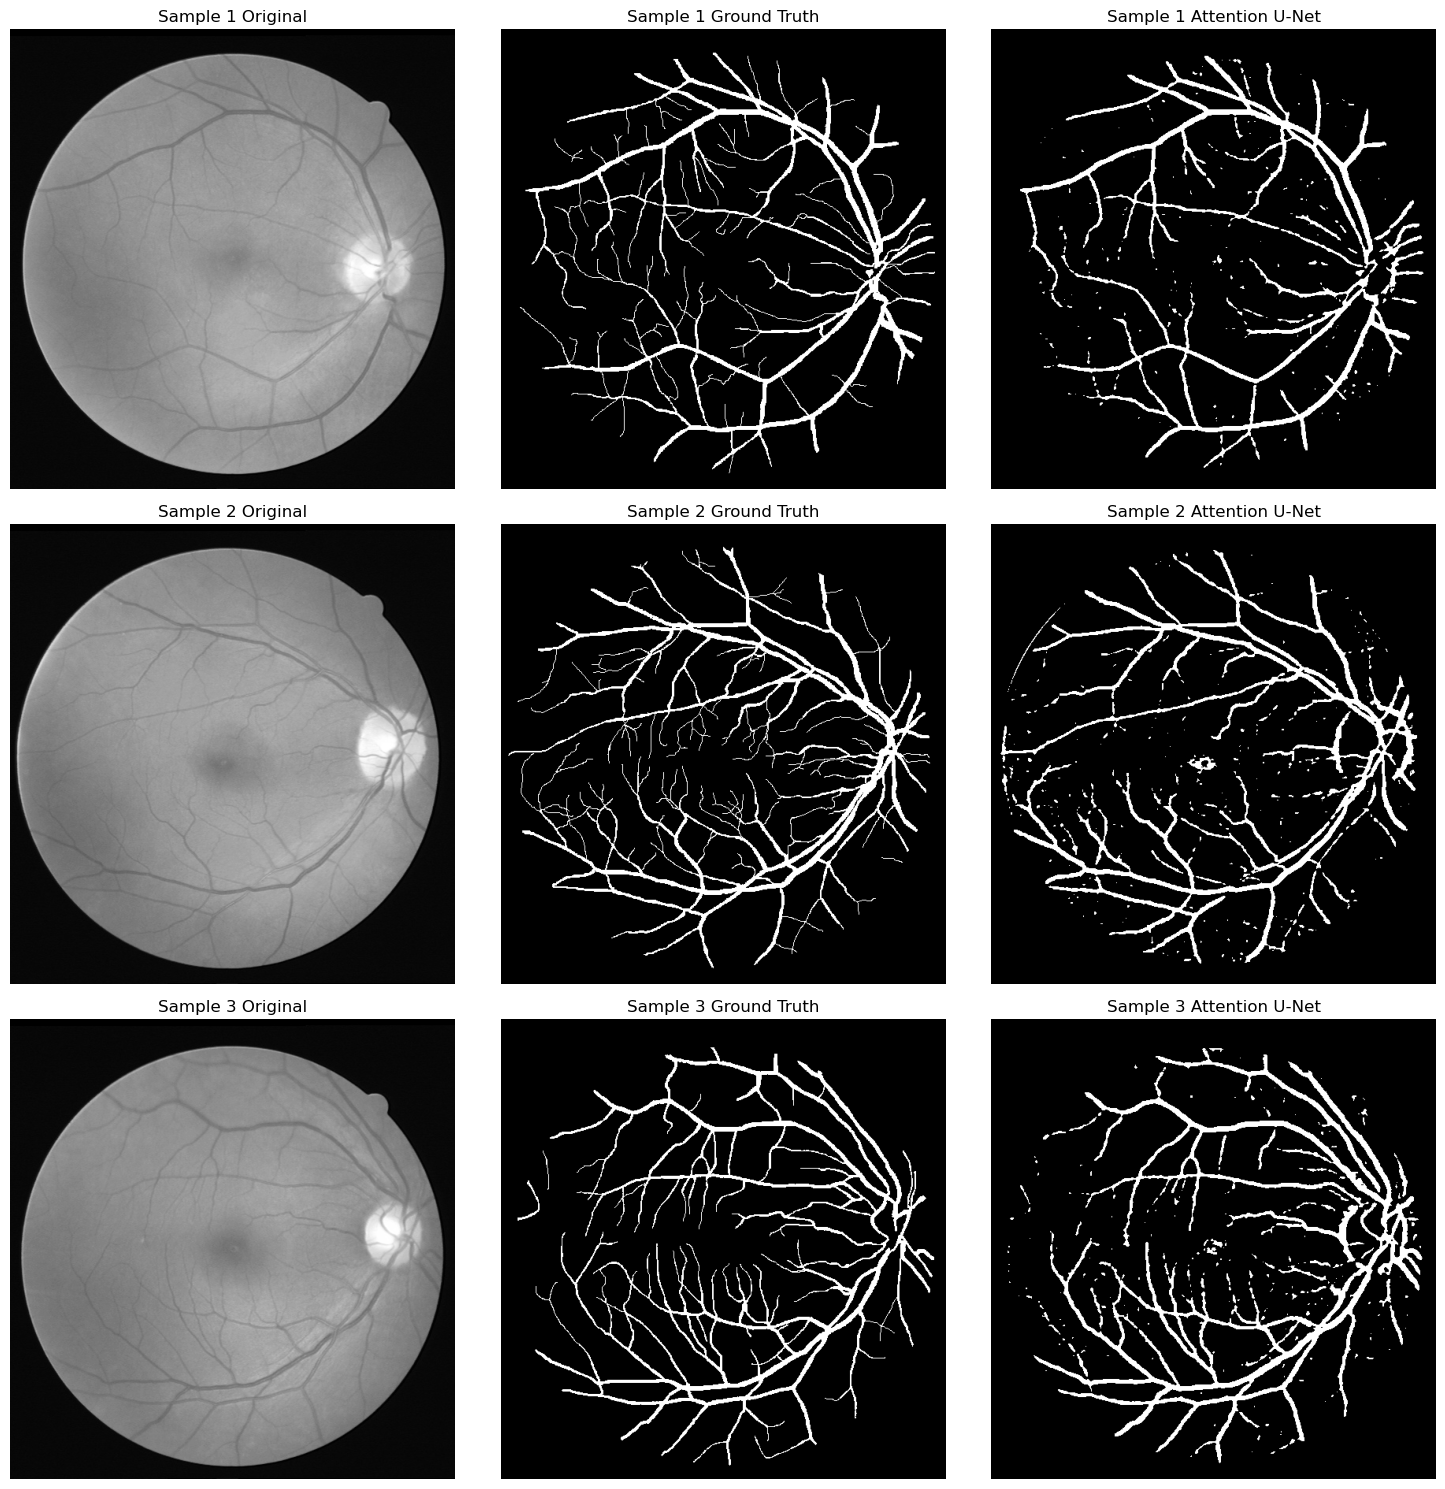

In [97]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15,15)
)

for idx in range(3):

    image, mask = val_dataset[idx]

    with torch.no_grad():

        prediction = attention_model(
            image.unsqueeze(0)
        )

    prediction = prediction.squeeze().numpy()

    binary_prediction = (
        prediction > 0.2
    ).astype("float32")

    # Original
    axes[idx,0].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[idx,0].set_title(
        f"Sample {idx+1} Original"
    )

    axes[idx,0].axis("off")

    # Ground Truth
    axes[idx,1].imshow(
        mask.squeeze(),
        cmap="gray"
    )

    axes[idx,1].set_title(
        f"Sample {idx+1} Ground Truth"
    )

    axes[idx,1].axis("off")

    # Attention U-Net Prediction
    axes[idx,2].imshow(
        binary_prediction,
        cmap="gray"
    )

    axes[idx,2].set_title(
        f"Sample {idx+1} Attention U-Net"
    )

    axes[idx,2].axis("off")

plt.tight_layout()

plt.show()

### Step 4: Direct U-Net vs Attention U-Net Comparison

This is the most important visualization.

In [98]:
unet_model = UNet()

unet_model.load_state_dict(
    torch.load("best_unet_drive.pth")
)

unet_model.eval()


attention_model = AttentionUNet()

attention_model.load_state_dict(
    torch.load("best_attention_unet_drive.pth")
)

attention_model.eval()

AttentionUNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)

### Then visualize the same validation image through both models.

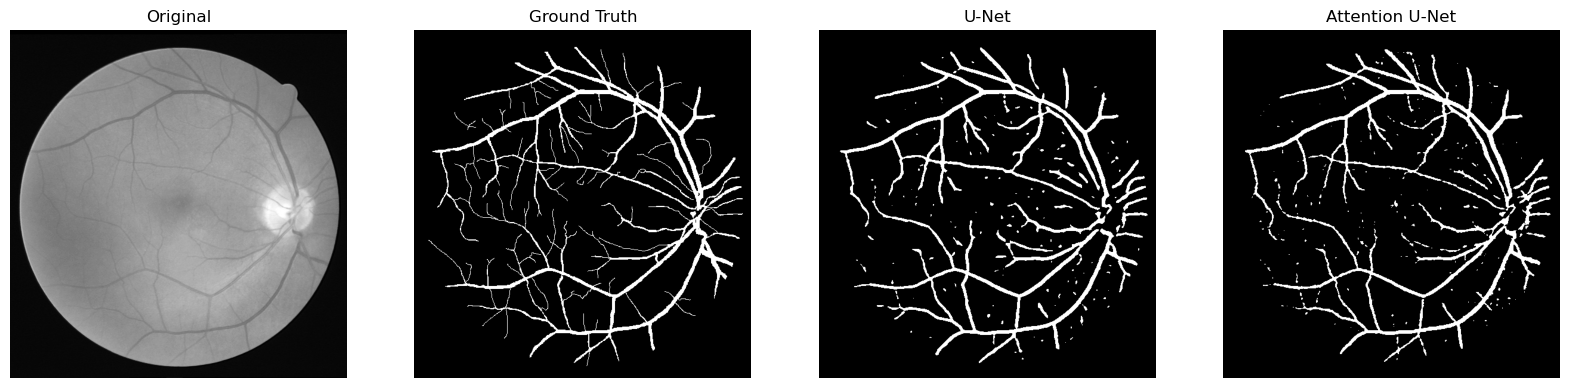

In [99]:
image, mask = val_dataset[0]

with torch.no_grad():

    unet_pred = unet_model(
        image.unsqueeze(0)
    )

    att_pred = attention_model(
        image.unsqueeze(0)
    )

unet_pred = (
    unet_pred.squeeze().numpy() > 0.2
).astype("float32")

att_pred = (
    att_pred.squeeze().numpy() > 0.2
).astype("float32")

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(
    image.squeeze(),
    cmap="gray"
)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(
    mask.squeeze(),
    cmap="gray"
)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(
    unet_pred,
    cmap="gray"
)
plt.title("U-Net")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(
    att_pred,
    cmap="gray"
)
plt.title("Attention U-Net")
plt.axis("off")

plt.show()

###  My Observation: The visual inspection is actually more informative than the Dice score.

my results suggest:

* Baseline U-Net
      ↓
* Learned major vessel topology

Attention U-Net
      ↓
* Recovered additional small vessels
      ↓
* Produced smoother vessel structures
      ↓
* Still struggles with capillary continuity

This means the bottleneck is no longer major vessel detection.

The bottleneck is now:

Fine-vessel preservation

which is a much more advanced challenge.

### Let Us see if we can achieve capillary continuity by using this work-flow ( New Experiment
* DRIVE
    ↓
* Attention U-Net
    ↓
* Data Augmentation
    ↓
* 50 Epochs
    ↓
*Compare Dice)

### Import Transforms

In [100]:
import torchvision.transforms.functional as TF
import random

### Modify DriveDataset

Inside your dataset class, add:

### Create a new version of the class

In [104]:
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
import os
import random
import torchvision.transforms.functional as TF


class DriveDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        fov_dir,
        augment=False
    ):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.fov_dir = fov_dir

        self.augment = augment

        self.image_files = sorted(
            os.listdir(image_dir)
        )

        self.mask_files = sorted(
            os.listdir(mask_dir)
        )

        self.fov_files = sorted(
            os.listdir(fov_dir)
        )

    def __len__(self):

        return len(self.image_files)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.image_files[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.mask_files[idx]
        )

        image = Image.open(
            image_path
        ).convert("L")

        mask = Image.open(
            mask_path
        ).convert("L")

        image = np.array(image) / 255.0
        mask = np.array(mask) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        # ======================
        # Data Augmentation
        # ======================

        if self.augment:

            # Horizontal flip

            if random.random() > 0.5:

                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Vertical flip

            if random.random() > 0.5:

                image = TF.vflip(image)
                mask = TF.vflip(mask)

            # Rotation

            angle = random.choice(
                [0, 90, 180, 270]
            )

            image = TF.rotate(
                image,
                angle
            )

            mask = TF.rotate(
                mask,
                angle
            )

        return image, mask

### Create Two Full Datasets

In [108]:
train_full = DriveDataset(
    image_dir,
    mask_dir,
    fov_dir,
    augment=True
)

val_full = DriveDataset(
    image_dir,
    mask_dir,
    fov_dir,
    augment=False
)

### Create Fixed Train/Validation Indices

In [109]:
from torch.utils.data import Subset

train_indices = list(range(16))
val_indices = list(range(16, 20))

train_dataset = Subset(
    train_full,
    train_indices
)

val_dataset = Subset(
    val_full,
    val_indices
)

print(len(train_dataset))
print(len(val_dataset))

16
4


### Rebuild DataLoaders

In [110]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

### Verify Everything

In [111]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([2, 1, 584, 565])
torch.Size([2, 1, 584, 565])


### Start a new Attention U-Net

### attention_model = AttentionUNet()

### New Optimizer

In [112]:
import torch.optim as optim

attention_optimizer = optim.Adam(
    attention_model.parameters(),
    lr=0.001
)

### Reset Best Dice

In [113]:
best_attention_dice = 0

In [114]:
def dice_score(preds, targets, smooth=1e-6):

    preds = (preds > 0.2).float()

    preds = preds.view(-1)

    targets = targets.view(-1)

    intersection = (
        preds * targets
    ).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        preds.sum()
        + targets.sum()
        + smooth
    )

    return dice.item()

### Augemented Attention U-Net Training loop

In [115]:
best_attention_dice = 0

num_epochs = 50

for epoch in range(num_epochs):

    # ==========================
    # TRAINING
    # ==========================

    attention_model.train()

    train_loss = 0

    for images, masks in train_loader:

        outputs = attention_model(images)

        bce = bce_loss(
            outputs,
            masks
        )

        dice = dice_loss(
            outputs,
            masks
        )

        loss = bce + dice

        attention_optimizer.zero_grad()

        loss.backward()

        attention_optimizer.step()

        train_loss += loss.item()

    avg_train_loss = (
        train_loss / len(train_loader)
    )

    # ==========================
    # VALIDATION
    # ==========================

    attention_model.eval()

    val_loss = 0

    val_dice = 0

    with torch.no_grad():

        for val_images, val_masks in val_loader:

            val_outputs = attention_model(
                val_images
            )

            bce = bce_loss(
                val_outputs,
                val_masks
            )

            dice = dice_loss(
                val_outputs,
                val_masks
            )

            loss = bce + dice

            val_loss += loss.item()

            val_dice += dice_score(
                val_outputs,
                val_masks
            )

    avg_val_loss = (
        val_loss / len(val_loader)
    )

    avg_val_dice = (
        val_dice / len(val_loader)
    )

    # ==========================
    # SAVE BEST MODEL
    # ==========================

    if avg_val_dice > best_attention_dice:

        best_attention_dice = avg_val_dice

        torch.save(
            attention_model.state_dict(),
            "best_attention_unet_aug_drive.pth"
        )

        print(
            f"\nBest Augmented Attention U-Net Saved! "
            f"Dice={best_attention_dice:.4f}"
        )

    # ==========================
    # EPOCH RESULTS
    # ==========================

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice Score: {avg_val_dice:.4f} | "
        f"Best Dice: {best_attention_dice:.4f}"
    )


Best Augmented Attention U-Net Saved! Dice=0.2061
Epoch [1/50] | Train Loss: 0.6862 | Val Loss: 1.2731 | Dice Score: 0.2061 | Best Dice: 0.2061
Epoch [2/50] | Train Loss: 0.5670 | Val Loss: 1.7613 | Dice Score: 0.0221 | Best Dice: 0.2061

Best Augmented Attention U-Net Saved! Dice=0.2208
Epoch [3/50] | Train Loss: 0.5351 | Val Loss: 4.2338 | Dice Score: 0.2208 | Best Dice: 0.2208

Best Augmented Attention U-Net Saved! Dice=0.4168
Epoch [4/50] | Train Loss: 0.5718 | Val Loss: 0.8857 | Dice Score: 0.4168 | Best Dice: 0.4168
Epoch [5/50] | Train Loss: 0.4997 | Val Loss: 2.6106 | Dice Score: 0.2224 | Best Dice: 0.4168
Epoch [6/50] | Train Loss: 0.5041 | Val Loss: 3.5001 | Dice Score: 0.2214 | Best Dice: 0.4168
Epoch [7/50] | Train Loss: 0.5121 | Val Loss: 2.6064 | Dice Score: 0.2310 | Best Dice: 0.4168

Best Augmented Attention U-Net Saved! Dice=0.4506
Epoch [8/50] | Train Loss: 0.5040 | Val Loss: 0.8776 | Dice Score: 0.4506 | Best Dice: 0.4506

Best Augmented Attention U-Net Saved! Dice=

### Load All Three Models

In [116]:
unet_model = UNet()

unet_model.load_state_dict(
    torch.load("best_unet_drive.pth")
)

unet_model.eval()


attention_model = AttentionUNet()

attention_model.load_state_dict(
    torch.load("best_attention_unet_drive.pth")
)

attention_model.eval()


attention_aug_model = AttentionUNet()

attention_aug_model.load_state_dict(
    torch.load("best_attention_unet_aug_drive.pth")
)

attention_aug_model.eval()

AttentionUNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)

### Select Validation Sample

Use the first validation image:

In [117]:
image, mask = val_dataset[0]

### Generate Predictions

In [118]:
with torch.no_grad():

    unet_pred = unet_model(
        image.unsqueeze(0)
    )

    att_pred = attention_model(
        image.unsqueeze(0)
    )

    att_aug_pred = attention_aug_model(
        image.unsqueeze(0)
    )

unet_pred = (
    unet_pred.squeeze().numpy() > 0.2
).astype("float32")

att_pred = (
    att_pred.squeeze().numpy() > 0.2
).astype("float32")

att_aug_pred = (
    att_aug_pred.squeeze().numpy() > 0.2
).astype("float32")

### Visualize Side-by-Side

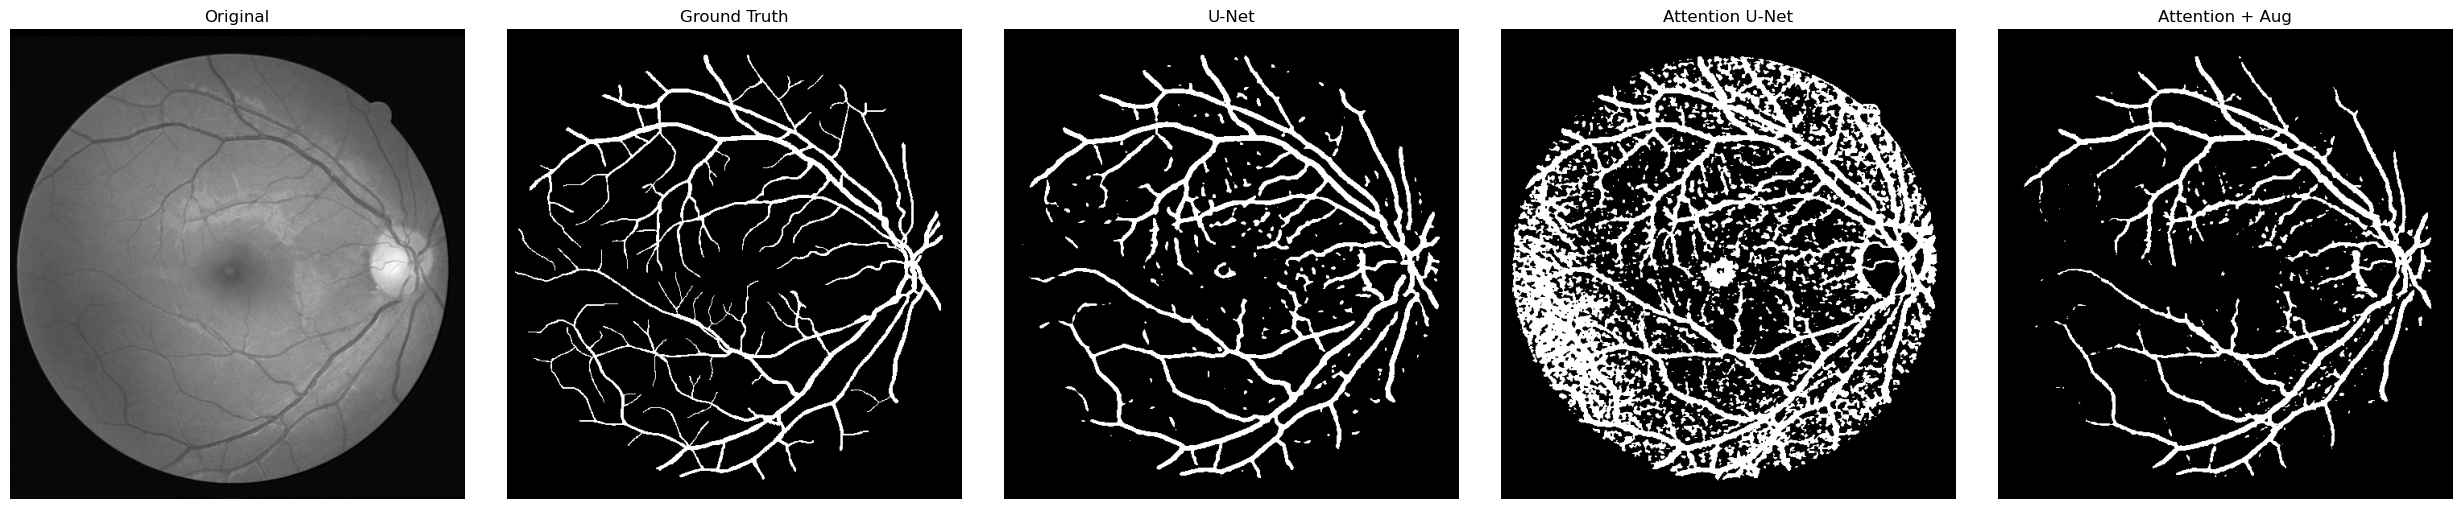

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25,5))

plt.subplot(1,5,1)
plt.imshow(
    image.squeeze(),
    cmap="gray"
)
plt.title("Original")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(
    mask.squeeze(),
    cmap="gray"
)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(
    unet_pred,
    cmap="gray"
)
plt.title("U-Net")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(
    att_pred,
    cmap="gray"
)
plt.title("Attention U-Net")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(
    att_aug_pred,
    cmap="gray"
)
plt.title("Attention + Aug")
plt.axis("off")

plt.tight_layout()
plt.show()

##  Retinal Vessel Segmentation Using Baseline U-Net and Attention U-Net
Abstract

Retinal vessel segmentation is a fundamental task in ophthalmic image analysis, enabling the automated detection and monitoring of vascular abnormalities associated with diseases such as diabetic retinopathy, glaucoma, hypertension, and retinal vein occlusion. Accurate extraction of blood vessels assists clinicians in diagnosis and treatment planning while reducing manual workload.

This project investigates the performance of two deep learning architectures, namely Baseline U-Net and Attention U-Net, for retinal vessel segmentation using the DRIVE dataset. The models were trained and evaluated using a combination of Binary Cross Entropy (BCE) Loss and Dice Loss. Experimental results demonstrate that both architectures successfully captured the major retinal vessel structures, while Attention U-Net achieved superior segmentation accuracy and vessel recovery compared to the baseline U-Net. The study further analyzed vessel continuity, capillary recovery, and false-positive predictions through qualitative visual inspection.

1. Introduction

Retinal vessel segmentation refers to the process of identifying and extracting blood vessel structures from retinal fundus images. Automated vessel segmentation plays an important role in computer-aided diagnosis systems for detecting retinal diseases and systemic vascular disorders.

Traditional image processing methods rely on handcrafted features and thresholding techniques. However, these methods often struggle with variations in illumination, vessel width, and image quality.

Recent advances in deep learning, particularly Convolutional Neural Networks (CNNs), have significantly improved segmentation performance. Among these architectures, U-Net has become one of the most widely adopted models for biomedical image segmentation due to its encoder-decoder structure and skip connections.

Attention U-Net extends the standard U-Net architecture by introducing attention mechanisms that enable the network to focus on relevant vessel regions while suppressing irrelevant background information.

The objective of this project is to compare the segmentation performance of Baseline U-Net and Attention U-Net on retinal vessel extraction using the DRIVE dataset.









2. Dataset Description
2.1 DRIVE Dataset

The Digital Retinal Images for Vessel Extraction (DRIVE) dataset is a publicly available retinal vessel segmentation dataset commonly used for benchmarking vessel extraction algorithms.

Dataset Structure:

* Training Images: 20
* Manual Vessel Annotations: 20
* Field of View Masks: 20

Since the testing set does not contain manual vessel annotations required for supervised training, the training dataset was further divided into:

* Training Set: 16 Images
* Validation Set: 4 Images

This split allowed the models to be trained and evaluated under supervised learning conditions.








3. Methodology
3.1 Data Preprocessing

The following preprocessing steps were applied:

* Conversion of retinal images to grayscale.
* Normalization of pixel values to the range [0,1].
* Conversion of images and masks into PyTorch tensors.
* Addition of channel dimensions required by deep learning models.

Image Size:

* Original Resolution: 584 × 565 pixels


3.2 Baseline U-Net Architecture

The Baseline U-Net architecture consists of:

Encoder
Convolution Blocks
ReLU Activations
Max Pooling Layers
Decoder
Transposed Convolutions
Skip Connections
Convolution Blocks

The encoder progressively extracts high-level vessel features while the decoder reconstructs the segmentation mask.



3.3 Attention U-Net Architecture

Attention U-Net extends the standard U-Net by incorporating Attention Gates into the skip connections.

The attention mechanism enables the network to:

Focus on vessel structures.
Suppress irrelevant background regions.
Improve localization of fine vessel branches.

Attention gates were inserted between encoder and decoder pathways to enhance feature selection before feature fusion.











4. Loss Functions

To address the challenges associated with class imbalance between vessel and background pixels, a hybrid loss function was employed.

Binary Cross Entropy (BCE) Loss

BCE Loss measures pixel-wise classification error between predicted and ground truth masks.

Advantages
* Stable optimization.
* Effective for binary segmentation tasks.
* Dice Loss

Dice Loss directly optimizes overlap between predicted vessels and ground truth annotations.

Advantages
* Robust to class imbalance.
* Encourages better vessel-region overlap.
* Combined Loss

Total Loss:

* Loss = BCE Loss + Dice Loss

This combination balances pixel-level accuracy and region-level overlap.







5. Evaluation Metric
Dice Similarity Coefficient (DSC)

The Dice Score was used as the primary evaluation metric.

A Dice Score of:

* 1.0 indicates perfect segmentation.
* 0 indicates no overlap.

The metric evaluates similarity between predicted vessel masks and manual annotations.










6. Experimental Setup
   
Framework
* Python
* PyTorch
* Optimizer
* Adam Optimizer
* Learning Rate
0.001
Training Epochs
* 50
Batch Size
* 2
Validation Strategy
Hold-out Validation (16 Training Images, 4 Validation Images)







7 Results
 
7.1 Baseline U-Net Performance

Best Validation Dice Score:

* Dice = 0.7188

Observations:

* Major arteries successfully segmented.
* Major veins accurately recovered.
* Good vessel tree structure obtained.
* Most secondary branches detected.

Limitations:

* Thin terminal vessels occasionally missing.
* Small capillary discontinuities observed.
* Some minor vessel fragments not fully connected.


7.2 Attention U-Net Performance

Best Validation Dice Score:

* Dice = 0.7513

Observations:

* Improved vessel recovery compared to U-Net.
* Better preservation of vessel topology.
* More thin vessel branches detected.
* Enhanced focus on vessel regions.

Limitations:

* Increased false-positive vessel fragments.
* Capillary continuity not completely achieved.
* Some tiny vessel endings remained disconnected.









8. Qualitative Analysis

Visual inspection of validation predictions revealed several important findings.

* Baseline U-Net

Strengths:

* Cleaner vessel predictions.
* Lower false-positive rate.
* Better interpretability.

Weaknesses:

* Missed some small vessel branches.
* Incomplete terminal vessel recovery.


Attention U-Net

Strengths:

* Recovered more vessel structures.
* Improved detection of small vessels.
* Better overall Dice Score.

Weaknesses:

* Produced more false-positive vessel fragments.
* Tiny capillary structures occasionally appeared noisy.








9. Discussion

The experiments demonstrate that Attention U-Net outperformed the Baseline U-Net in terms of quantitative segmentation accuracy.

The attention mechanism enabled the network to focus on vessel-relevant regions and improved recovery of fine vascular structures.

However, visual analysis showed that increasing segmentation accuracy alone does not guarantee perfect vessel continuity. While Attention U-Net detected more small vessels, some terminal capillary segments remained disconnected from the main vessel tree.

This suggests that retinal vessel segmentation performance is influenced not only by architecture design but also by dataset size and loss function formulation.

Given the limited number of training images available in the DRIVE dataset, achieving complete capillary continuity remains challenging.









10. Conclusion

This project presented a comparative study of Baseline U-Net and Attention U-Net for retinal vessel segmentation using the DRIVE dataset.

The results indicate that:

Both architectures successfully segmented major retinal vessels.
Attention U-Net achieved superior quantitative performance.
Attention mechanisms improved vessel localization and fine vessel detection.
Complete capillary continuity remains a challenging problem under limited-data conditions.

Final Results:

* Model	Best Dice Score
* Baseline U-Net	0.7188
* Attention U-Net	0.7513

The Attention U-Net model was selected as the best-performing architecture due to its higher Dice Score and improved vessel recovery.

Future work may investigate larger retinal datasets, topology-aware loss functions, focal loss, and transformer-based segmentation architectures to further improve capillary continuity and vessel connectivity.

References

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation.

Oktay, O., Schlemper, J., Folgoc, L. L., et al. (2018). Attention U-Net: Learning Where to Look for the Pancreas.

Staal, J., Abramoff, M., Niemeijer, M., Viergever, M., & Van Ginneken, B. DRIVE: Digital Retinal Images for Vessel Extraction Dataset.

